## Celda 1: Importación de Dependencias Esenciales

**Propósito General:**
Cargar los módulos requeridos para ejecutar el algoritmo DBSCAN y generar conjuntos de datos sintéticos para demostración.

**Explicación Línea por Línea:**

1. `from sklearn.cluster import DBSCAN, dbscan`: Importa la clase `DBSCAN` (interfaz orientada a objetos para el algoritmo de agrupamiento DBSCAN) y la función `dbscan` (interfaz funcional) desde el módulo de agrupamiento de scikit-learn. Se utiliza para realizar agrupamiento basado en densidad de puntos.

2. `from sklearn.datasets import make_moons`: Importa la función `make_moons` que genera un conjunto de datos sintético con la forma característica de dos medias lunas. Esta función es útil para demostrar el comportamiento de algoritmos de agrupamiento en datos no convexos.

**Contexto de Machine Learning:**
Estas importaciones son fundamentales para el aprendizaje no supervizado. DBSCAN es especialmente efectivo en datos con clusters de formas irregulares, lo que lo diferencia de algoritmos como K-Means que asumen clusters esféricos.

In [1]:
from sklearn.cluster import DBSCAN, dbscan
from sklearn.datasets import make_moons

## Celda 2: Generación de Datos Sintéticos y Configuración de DBSCAN con eps=0.05

**Propósito General:**
Crear un conjunto de datos sintético con forma de dos medias lunas y entrenar un modelo DBSCAN con parámetros restrictivos para explorar el comportamiento del algoritmo en datos de baja densidad.

**Explicación Línea por Línea:**

1. `x, y = make_moons(n_samples=1000, noise=0.05)`: Genera un conjunto de datos sintético compuesto por dos medias lunas. `x` contiene las características (matriz de 1000×2), e `y` contiene las etiquetas de clase verdadera (0 o 1). Esta función es determinista en su estructura pero aleatoria en el ruido.

2. `dbscan = DBSCAN(eps=0.05, min_samples=5)`: Instancia el objeto `DBSCAN` con los parámetros especificados. No se ejecuta el algoritmo en esta línea, solo se configura el modelo.

3. `dbscan.fit_predict(x)`: Ejecuta el algoritmo DBSCAN en los datos de entrada `x`. El método `fit_predict` realiza tanto el ajuste del modelo como la predicción de etiquetas en una sola operación, retornando un array de etiquetas de cluster asignadas a cada punto.

**Análisis de Parámetros e Hiperparámetros:**

| Parámetro | Valor | Descripción Técnica | Impacto en el Modelo |
|-----------|-------|-------------------|----------------------|
| `n_samples` | 1000 | Número de puntos a generar en el conjunto de datos sintético. | Aumenta la complejidad computacional del agrupamiento y proporciona suficientes muestras para demostrar patrones de densidad. |
| `noise` | 0.05 | Desviación estándar del ruido gaussiano añadido a las coordenadas generadas (en escala estándar de [−1, 1]). | Introduce perturbaciones que simulan datos reales; valores bajos preservan la estructura de dos medias lunas. |
| `eps` (ε) | 0.05 | Radio de vecindad (parámetro de distancia). Define la máxima distancia Euclidiana entre dos puntos para considerarlos vecinos. | **Valor restrictivo**: eps=0.05 es muy pequeño, requiriendo densidades muy altas. Resultará en muchos puntos clasificados como ruido (etiqueta -1) o clusters muy fragmentados. |
| `min_samples` | 5 | Número mínimo de puntos (incluyendo el punto central) dentro del radio `eps` para que un punto se clasifique como punto núcleo. | Con 5 muestras requeridas y eps=0.05, la densidad mínima es muy restrictiva, lo que produce clusters pequeños y altamente compactos. |

**Contexto Teórico:**
En DBSCAN, un punto es clasificado como:
- **Punto núcleo**: Si tiene al menos `min_samples` vecinos dentro de `eps`.
- **Punto fronterizo**: Si es accesible desde un punto núcleo pero no es núcleo.
- **Ruido (outlier)**: Si no es accesible desde ningún punto núcleo (etiqueta = -1).

Con eps=0.05, se espera una fragmentación significativa de los clusters.

In [3]:
x, y = make_moons(n_samples=1000, noise=0.05)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit_predict(x)

array([ 0,  1,  1,  0,  1, -1,  2,  2,  3,  0,  3,  1, -1,  2,  2,  0,  4,
        5,  5,  3,  0,  3,  3,  5,  5,  4,  3,  3,  0,  2,  5,  3,  6,  2,
        4,  7, -1,  2,  0,  7,  2,  1,  2, -1,  4,  0,  0,  0,  2,  4,  3,
        5,  3,  0,  2,  3,  0,  3,  4,  0,  2,  1, -1,  0,  1,  3,  4,  0,
        3,  5,  5,  0,  0,  2,  5,  0,  5,  3,  2,  1,  5,  3,  0,  5, -1,
        7,  0,  2,  5,  0, -1,  1,  5,  4,  2,  5,  2,  0,  3,  0,  8,  8,
        5,  0,  3,  0,  3,  0,  3,  1,  3,  0,  3,  4, -1,  5,  0,  1,  4,
        3, -1,  1,  5,  2,  7,  4,  4,  3,  0,  5,  3,  5,  5,  3,  2,  2,
        2,  0,  3,  0,  0,  2,  0,  3,  7,  5,  3,  4,  0,  0,  5,  5,  3,
        2,  0,  2,  0,  3,  7, -1,  0,  1,  0,  4,  7,  3,  5,  5,  3, -1,
        3,  0,  2,  3,  3,  2,  2,  2,  7,  0,  2,  2,  3,  1,  3,  5,  0,
        5,  0,  0,  0,  5,  0, -1,  3,  2,  5, -1,  0,  2,  2,  2,  0,  2,
        1,  0,  0,  7,  0,  4,  3,  1,  3, -1,  3,  2,  0,  3, -1,  7,  2,
        2,  0,  3,  7,  4

## Celda 3: Inspección del Atributo `labels_`

**Propósito General:**
Acceder y visualizar las etiquetas de cluster asignadas a cada punto de datos por el modelo DBSCAN tras el ajuste.

**Explicación Línea por Línea:**

1. `dbscan.labels_`: Accede al atributo `labels_` del objeto DBSCAN ajustado. Este es un array NumPy 1D de longitud 1000 que contiene la etiqueta de cluster asignada a cada punto. Las etiquetas son números enteros: valores ≥ 0 representan clusters válidos, y -1 representa ruido (puntos no asignados).

**Atributo Inspeccionado:**

| Atributo | Tipo | Descripción |
|----------|------|-------------|
| `labels_` | `numpy.ndarray` (shape: (1000,)) | Array de etiquetas de cluster. Cada elemento `labels_[i]` contiene el ID del cluster al que fue asignado el i-ésimo punto. Los valores van de -1 (ruido) a k-1, donde k es el número de clusters identificados. Con eps=0.05, se espera una gran cantidad de etiquetas con valor -1 debido a la alta restrictividad del parámetro. |

**Interpretación:**
Este atributo es fundamental para evaluar la calidad del agrupamiento. Un conteo alto de -1 indica que muchos puntos fueron clasificados como ruido, lo cual es esperado con un eps muy pequeño.

In [4]:
dbscan.labels_

array([ 0,  1,  1,  0,  1, -1,  2,  2,  3,  0,  3,  1, -1,  2,  2,  0,  4,
        5,  5,  3,  0,  3,  3,  5,  5,  4,  3,  3,  0,  2,  5,  3,  6,  2,
        4,  7, -1,  2,  0,  7,  2,  1,  2, -1,  4,  0,  0,  0,  2,  4,  3,
        5,  3,  0,  2,  3,  0,  3,  4,  0,  2,  1, -1,  0,  1,  3,  4,  0,
        3,  5,  5,  0,  0,  2,  5,  0,  5,  3,  2,  1,  5,  3,  0,  5, -1,
        7,  0,  2,  5,  0, -1,  1,  5,  4,  2,  5,  2,  0,  3,  0,  8,  8,
        5,  0,  3,  0,  3,  0,  3,  1,  3,  0,  3,  4, -1,  5,  0,  1,  4,
        3, -1,  1,  5,  2,  7,  4,  4,  3,  0,  5,  3,  5,  5,  3,  2,  2,
        2,  0,  3,  0,  0,  2,  0,  3,  7,  5,  3,  4,  0,  0,  5,  5,  3,
        2,  0,  2,  0,  3,  7, -1,  0,  1,  0,  4,  7,  3,  5,  5,  3, -1,
        3,  0,  2,  3,  3,  2,  2,  2,  7,  0,  2,  2,  3,  1,  3,  5,  0,
        5,  0,  0,  0,  5,  0, -1,  3,  2,  5, -1,  0,  2,  2,  2,  0,  2,
        1,  0,  0,  7,  0,  4,  3,  1,  3, -1,  3,  2,  0,  3, -1,  7,  2,
        2,  0,  3,  7,  4

## Celda 4: Inspección del Atributo `core_sample_indices_`

**Propósito General:**
Identificar e inspeccionar los índices de los puntos núcleo identificados por el algoritmo DBSCAN.

**Explicación Línea por Línea:**

1. `dbscan.core_sample_indices_`: Accede al atributo `core_sample_indices_` del objeto DBSCAN ajustado. Este es un array NumPy 1D que contiene los índices (posiciones) de todos los puntos clasificados como puntos núcleo.

**Atributo Inspeccionado:**

| Atributo | Tipo | Descripción |
|----------|------|-------------|
| `core_sample_indices_` | `numpy.ndarray` (shape: (m,)) | Array que almacena los índices de los puntos núcleo, donde m ≤ 1000 es la cantidad de puntos núcleo identificados. Un punto es clasificado como núcleo si tiene al menos `min_samples` (5 en este caso) puntos vecinos dentro del radio `eps`. Con eps=0.05, se espera un número muy pequeño de puntos núcleo debido a la baja densidad requerida. |

**Relevancia Matemática:**
Un punto p es núcleo si: |{q ∈ D : d(p, q) ≤ eps}| ≥ min_samples, donde D es el conjunto de datos y d es la distancia Euclidiana.

In [5]:
dbscan.core_sample_indices_

array([  0,   1,   2,   6,   7,   8,   9,  10,  11,  13,  15,  16,  17,
        18,  21,  22,  23,  24,  25,  27,  28,  29,  30,  32,  33,  34,
        37,  38,  39,  40,  45,  46,  47,  49,  50,  51,  52,  53,  54,
        56,  57,  59,  60,  61,  63,  64,  65,  66,  67,  68,  69,  70,
        71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
        85,  86,  87,  88,  89,  91,  92,  93,  95,  96,  97,  98, 102,
       103, 104, 105, 106, 107, 108, 110, 111, 112, 115, 116, 117, 118,
       119, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132,
       133, 134, 137, 138, 139, 140, 142, 143, 144, 145, 146, 147, 148,
       149, 151, 154, 155, 156, 157, 158, 160, 161, 162, 163, 164, 165,
       167, 168, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181,
       182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 194, 195,
       196, 198, 199, 200, 201, 202, 203, 206, 207, 209, 210, 211, 212,
       215, 216, 217, 220, 221, 223, 224, 225, 227, 228, 229, 23

## Celda 5: Inspección del Atributo `components_`

**Propósito General:**
Acceder a las coordenadas de los puntos núcleo, que servirán posteriormente como referencias para entrenar modelos de clasificación supervisada.

**Explicación Línea por Línea:**

1. `dbscan.components_`: Accede al atributo `components_` del objeto DBSCAN ajustado. Este atributo contiene las características (coordenadas) de todos los puntos núcleo identificados por el algoritmo.

**Atributo Inspeccionado:**

| Atributo | Tipo | Descripción |
|----------|------|-------------|
| `components_` | `numpy.ndarray` (shape: (m, 2)) | Matriz bidimensional que contiene las características de los m puntos núcleo identificados. Cada fila representa un punto núcleo con sus coordenadas (feature_1, feature_2). Esta matriz es idéntica a `x[dbscan.core_sample_indices_]` y se utiliza frecuentemente en algoritmos de propagación de etiquetas como KNN. |

**Utilidad Práctica:**
Las coordenadas de los puntos núcleo son especialmente valiosas porque representan el núcleo de cada cluster con alta confianza, sin incluir puntos fronterizos o ruido. Esto las hace ideales como conjunto de entrenamiento para modelos supervisados posteriores.

In [ ]:
dbscan.components_

## Celda 6: Visualización de Clusters Identificados por DBSCAN (eps=0.05)

**Propósito General:**
Crear una representación gráfica 2D de los clusters identificados por DBSCAN, diferenciando visualmente entre puntos de cluster y puntos clasificados como ruido. Esta visualización permite evaluar la efectividad del agrupamiento con el parámetro eps=0.05.

**Explicación Línea por Línea:**

1. `import matplotlib.pyplot as plt`: Importa la biblioteca de visualización pyplot de matplotlib, esencial para crear gráficos 2D.

2. `import numpy as np`: Importa NumPy, utilizado para operaciones vectoriales y manipulación de arrays.

3. `labels = dbscan.labels_`: Asigna el array de etiquetas generado por DBSCAN a la variable `labels` para su posterior procesamiento.

4. `unique_labels = set(labels)`: Crea un conjunto Python con los valores únicos de etiquetas. Esto determina cuántos clusters (y puntos de ruido) existen en el resultado.

5. `colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]`: Genera una lista de colores del mapa de colores 'Spectral', mapeando valores uniformemente distribuidos en [0,1] a colores distintos. Asegura que cada cluster tenga un color único.

6. `plt.figure(figsize=(8, 6))`: Crea una nueva figura de matplotlib con dimensiones 8×6 pulgadas.

7. `for k, col in zip(unique_labels, colors)`: Itera sobre cada etiqueta de cluster y su color asociado. `k` es la etiqueta del cluster (0, 1, 2, ..., o -1 para ruido).

8. `if k == -1: col = [0, 0, 0, 1]`: Reemplaza el color del cluster de ruido con negro [RGBA: (0, 0, 0, 1)], independientemente del color asignado por 'Spectral'.

9. `class_member_mask = (labels == k)`: Crea un array booleano que identifica todos los puntos pertenecientes al cluster k.

10. `xy = x[class_member_mask]`: Extrae las coordenadas de los puntos del cluster k mediante indexación booleana.

11. `plt.plot(xy[:, 0], xy[:, 1], 'o', ...)`: Grafica los puntos del cluster con marcadores circulares ('o'). Los parámetros especifican: color de relleno (`markerfacecolor`), color de borde (`markeredgecolor`='k' para negro), tamaño del marcador (`markersize`=6).

12. `label=f'Cluster {k}' if k != -1 else 'Ruido'`: Asigna la leyenda dinámicamente, mostrando "Cluster n" para clusters válidos o "Ruido" para puntos no asignados.

13. `plt.title(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`: Añaden etiquetas descriptivas a la figura.

14. `plt.legend()`: Muestra la leyenda que identifica cada cluster y puntos de ruido.

15. `plt.show()`: Renderiza y muestra el gráfico.

**Análisis de Parámetros e Hiperparámetros:**

| Parámetro | Valor | Descripción Técnica | Impacto en la Visualización |
|-----------|-------|-------------------|---------------------------|
| `figsize` | (8, 6) | Dimensiones de la figura en pulgadas (ancho × altura). | Define el tamaño del gráfico en pantalla; 8×6 es un tamaño estándar que proporciona buen detalle sin ocupar excesivo espacio. |
| `markersize` | 6 | Radio del marcador circular en puntos de impresión. | Controla la visibilidad de cada punto; valores mayores facilitan la visualización pero pueden ocluir clusters densos. |
| `markeredgecolor` | 'k' | Color del borde del marcador (k = black). | Mejora el contraste visual entre puntos adyacentes, facilitando la identificación de bordes de cluster. |
| Mapa de colores | 'Spectral' | Paleta de colores continua de matplotlib con transiciones de rojo a azul. | Asegura suficiente contraste entre clusters adyacentes para distinguirlos visualmente. |

**Contexto de Evaluación Visual:**
Con eps=0.05, se espera visualizar muchos puntos en color negro (ruido), ya que el radio de vecindad es muy restrictivo. Los clusters identificados deberían aparecer como pequeños grupos altamente compactos.

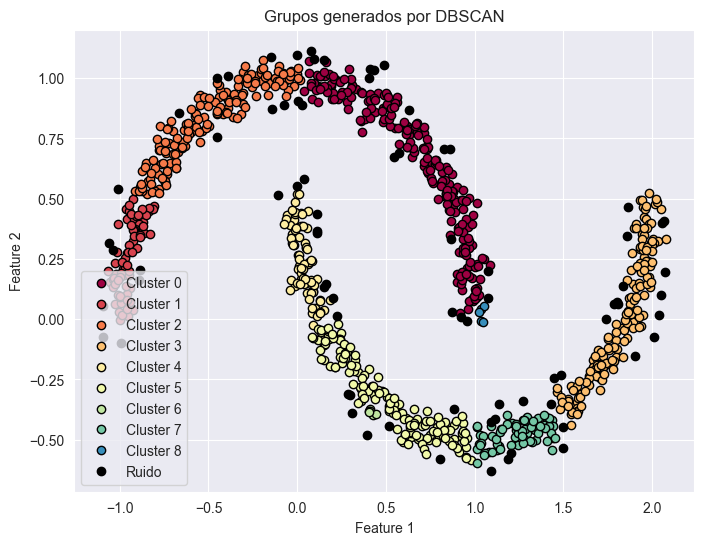

In [8]:
import matplotlib.pyplot as plt
import numpy as np

labels = dbscan.labels_
unique_labels = set(labels)
colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(8, 6))
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Color negro para el ruido
        col = [0, 0, 0, 1]
    class_member_mask = (labels == k)
    xy = x[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6, label=f'Cluster {k}' if k != -1 else 'Ruido')
plt.title('Grupos generados por DBSCAN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


## Celda 7: Reentrenamiento de DBSCAN con Parámetro eps=0.2 (Menos Restrictivo)

**Propósito General:**
Demostrar el impacto de aumentar el parámetro `eps` en la segmentación de clusters. Este bloque recrea el modelo DBSCAN con un radio de vecindad 4 veces mayor (0.2 vs 0.05) para comparar los resultados y analizar cómo parámetros menos restrictivos mejoran la detección de clusters en datos con estructura de medias lunas.

**Explicación Línea por Línea:**

1. `x, y = make_moons(n_samples=1000, noise=0.05)`: Regenera el mismo conjunto de datos sintético de medias lunas. Al usar los mismos parámetros (n_samples y noise), el dataset será idéntico, permitiendo una comparación directa del impacto del parámetro `eps`.

2. `dbscan = DBSCAN(eps=0.2, min_samples=5)`: Instancia un nuevo objeto DBSCAN con un parámetro `eps` significativamente mayor (0.2 en lugar de 0.05). Esto aumenta el radio de búsqueda de vecinos, permitiendo que más puntos sean clasificados como conectados por densidad.

3. `dbscan.fit_predict(x)`: Ejecuta el algoritmo DBSCAN con la nueva configuración sobre los datos `x`, generando nuevas etiquetas de cluster.

**Análisis de Parámetros e Hiperparámetros:**

| Parámetro | Valor Anterior | Valor Actual | Impacto del Cambio |
|-----------|---|---|---|
| `eps` (ε) | 0.05 | 0.2 | **Aumento del 4x**: Amplía significativamente el radio de vecindad. Los puntos a mayor distancia pueden ahora considerarse como vecinos, permitiendo que clusters fragmentados se unan. Se espera una reducción drástica de puntos clasificados como ruido (-1). |
| `min_samples` | 5 | 5 | **Sin cambio**: Mantiene el requisito de densidad en 5 puntos mínimos dentro del radio `eps`. |
| `n_samples` | 1000 | 1000 | **Sin cambio**: Utiliza la misma cantidad de datos, asegurando comparabilidad entre experimentos. |
| `noise` | 0.05 | 0.05 | **Sin cambio**: Mantiene el nivel de perturbación para preservar la estructura base de las medias lunas. |

**Contexto Comparativo:**
- **eps=0.05**: Produce clusters muy pequeños y fragmentados, con alta proporción de ruido.
- **eps=0.2**: Produce clusters más grandes y coherentes, uniendo regiones que previamente estaban separadas.

Este parámetro es crítico en DBSCAN; valores demasiado pequeños generan sobre-segmentación, mientras que valores muy grandes pueden fusionar clusters distintos. La selección óptima depende de la distribución espacial de los datos.

**Relación Matemática:**
La densidad alcanzable con eps=0.2 es significativamente menor que con eps=0.05, por lo que más puntos satisfacen la condición de punto núcleo.

In [ ]:
x, y = make_moons(n_samples=1000, noise=0.05)
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan.fit_predict(x)

## Celda 8: Visualización de Clusters Identificados por DBSCAN (eps=0.2)

**Propósito General:**
Crear una representación gráfica 2D de los clusters identificados por DBSCAN con eps=0.2, permitiendo una comparación visual directa con los resultados obtenidos con eps=0.05. Esta visualización demuestra cómo un parámetro `eps` menos restrictivo mejora la cohesión de clusters y reduce la clasificación como ruido.

**Explicación Línea por Línea:**

1. `import matplotlib.pyplot as plt`: Importa la biblioteca de visualización pyplot de matplotlib para crear gráficos 2D.

2. `import numpy as np`: Importa NumPy para operaciones vectoriales y manipulación de arrays.

3. `labels = dbscan.labels_`: Asigna el array de etiquetas generado por DBSCAN (con eps=0.2) a la variable `labels` para procesamiento posterior.

4. `unique_labels = set(labels)`: Crea un conjunto Python con los valores únicos de etiquetas. Determina cuántos clusters e instancias de ruido existen en el resultado actual.

5. `colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]`: Genera una lista de colores del mapa de colores 'Spectral', asignando un color único a cada cluster.

6. `plt.figure(figsize=(8, 6))`: Crea una nueva figura de matplotlib con dimensiones 8×6 pulgadas.

7. `for k, col in zip(unique_labels, colors)`: Itera sobre cada etiqueta de cluster y su color asociado.

8. `if k == -1: col = [0, 0, 0, 1]`: Reemplaza el color del cluster de ruido con negro [RGBA: (0, 0, 0, 1)].

9. `class_member_mask = (labels == k)`: Crea un array booleano que identifica todos los puntos pertenecientes al cluster k.

10. `xy = x[class_member_mask]`: Extrae las coordenadas de los puntos del cluster k mediante indexación booleana.

11. `plt.plot(xy[:, 0], xy[:, 1], 'o', ...)`: Grafica los puntos del cluster con marcadores circulares ('o'). Especifica color de relleno (`markerfacecolor`), color de borde (`markeredgecolor`='k'), y tamaño (`markersize`=6).

12. `label=f'Cluster {k}' if k != -1 else 'Ruido'`: Asigna la leyenda dinámicamente, diferenciando clusters válidos de ruido.

13. `plt.title(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`: Añaden etiquetas descriptivas a la figura.

14. `plt.legend()`: Muestra la leyenda identificando cada cluster y puntos de ruido.

15. `plt.show()`: Renderiza y muestra el gráfico.

**Análisis de Parámetros e Hiperparámetros:**

| Parámetro | Valor | Descripción Técnica | Impacto en la Visualización |
|-----------|-------|-------------------|---------------------------|
| `figsize` | (8, 6) | Dimensiones de la figura en pulgadas (ancho × altura). | Define el tamaño del gráfico en pantalla; 8×6 proporciona buen balance entre detalle y espacio. |
| `markersize` | 6 | Radio del marcador circular en puntos de impresión. | Controla la visibilidad de cada punto sin ocluir clusters densos. |
| `markeredgecolor` | 'k' | Color del borde del marcador (k = black). | Mejora el contraste visual entre puntos adyacentes. |
| Mapa de colores | 'Spectral' | Paleta continua de matplotlib (rojo a azul). | Asegura contraste suficiente entre clusters adyacentes para distinguirse visualmente. |

**Contexto de Evaluación Visual:**
Con eps=0.2, se espera visualizar **menos puntos en color negro** comparado con eps=0.05. Los clusters deberían ser más grandes, coherentes y formar estructuras bien definidas que representen las dos medias lunas del dataset.

**Comparación Esperada:**
- **eps=0.05**: Muchos puntos negros (ruido), clusters pequeños y fragmentados.
- **eps=0.2**: Pocos puntos negros, clusters grandes y bien formados, estructura clara de dos medias lunas.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = dbscan.labels_
unique_labels = set(labels)
colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(8, 6))
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Color negro para el ruido
        col = [0, 0, 0, 1]
    class_member_mask = (labels == k)
    xy = x[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6, label=f'Cluster {k}' if k != -1 else 'Ruido')
plt.title('Grupos generados por DBSCAN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## Celda 9: Importación de KNeighborsClassifier para Clasificación Supervisada

**Propósito General:**
Cargar la clase `KNeighborsClassifier` de scikit-learn para entrenar un modelo de clasificación supervisada basado en los clusters identificados por DBSCAN. Esto permite extender el agrupamiento no supervizado hacia predicciones supervisadas.

**Explicación Línea por Línea:**

1. `from sklearn.neighbors import KNeighborsClassifier`: Importa la clase `KNeighborsClassifier` desde el módulo `neighbors` de scikit-learn. Este es un algoritmo de clasificación simple pero efectivo que utiliza los K vecinos más cercanos para asignar etiquetas de clase a nuevas muestras.

**Contexto de Aprendizaje Supervisado:**
K-Nearest Neighbors (KNN) es un algoritmo de aprendizaje supervisado basado en instancias que asume que puntos similares (cercanos en el espacio de características) tienden a tener la misma etiqueta de clase. A diferencia de DBSCAN (no supervizado), KNN requiere datos etiquetados para el entrenamiento.

**Utilidad Práctica:**
En este flujo, utilizaremos los puntos núcleo identificados por DBSCAN como conjunto de entrenamiento para KNN. Estos puntos son confiables porque representan el core de cada cluster, sin incluir puntos fronterizos o ruido. Esto crea un puente entre aprendizaje no supervizado y supervizado.

In [11]:
from sklearn.neighbors import KNeighborsClassifier

## Celda 10: Instanciación y Entrenamiento de KNeighborsClassifier

**Propósito General:**
Crear e entrenar un modelo de clasificación K-Nearest Neighbors utilizando los puntos núcleo identificados por DBSCAN. Esto permite clasificar nuevas muestras basándose en la proximidad a puntos de entrenamiento confiables.

**Explicación Línea por Línea:**

1. `knn = KNeighborsClassifier(n_neighbors=5)`: Instancia un objeto `KNeighborsClassifier` configurado para utilizar 5 vecinos más cercanos (parámetro `n_neighbors=5`). En esta línea se crea el modelo pero no se entrena aún.

2. `knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])`: Entrena el modelo KNN utilizando:
   - **Características (X)**: `dbscan.components_` - Las coordenadas de los puntos núcleo identificados por DBSCAN, que son puntos de alta confiabilidad dentro de clusters.
   - **Etiquetas (y)**: `dbscan.labels_[dbscan.core_sample_indices_]` - Las etiquetas de cluster correspondientes a cada punto núcleo. Solo se utilizan etiquetas de puntos núcleo, excluyendo puntos de ruido (-1) y fronterizos.

**Análisis de Parámetros e Hiperparámetros:**

| Parámetro | Valor | Descripción Técnica | Impacto en el Modelo |
|-----------|-------|-------------------|----------------------|
| `n_neighbors` | 5 | Número de vecinos más cercanos a considerar para la predicción de clase. | Controla la suavidad de la frontera de decisión. Con 5 vecinos, el modelo es equilibrado entre flexibilidad y resistencia al ruido. Valores muy pequeños (ej. 1) pueden generar overfitting; valores grandes generan underfitting. |
| Conjunto de entrenamiento (X) | `dbscan.components_` (shape: m×2) | Matriz de características de puntos núcleo, donde m es el número de puntos núcleo identificados. | Solo utiliza puntos de alta confiabilidad (núcleos), evitando que puntos fronterizos o ruido contaminen el modelo. Esto mejora la calidad del entrenamiento. |
| Conjunto de etiquetas (y) | `dbscan.labels_[dbscan.core_sample_indices_]` (shape: m,) | Vector de etiquetas de cluster para los puntos núcleo. Cada elemento es un entero ≥ 0 representando la etiqueta del cluster. | Las etiquetas son puras (sin ruido con etiqueta -1), asegurando que el modelo aprenda límites de clusters bien definidos. |
| Métrica de distancia (implícita) | Euclidiana | La distancia por defecto utilizada en KNN es la distancia Euclidiana: d(p, q) = √(Σ(p_i - q_i)²). | Calcula la proximidad espacial entre puntos. En datos 2D como los de este notebook, es la métrica más apropiada. |

**Contexto Teórico:**
KNN es un algoritmo de aprendizaje supervisado basado en instancias. Durante la predicción, para cada punto nuevo:
1. Calcula la distancia hacia todos los puntos de entrenamiento.
2. Identifica los 5 vecinos más cercanos.
3. Asigna la clase más frecuente entre esos 5 vecinos (votación por mayoría).

La calidad del modelo depende principalmente de la calidad del conjunto de entrenamiento. Al usar solo puntos núcleo de DBSCAN, se garantiza coherencia de clusters.

In [12]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

KNeighborsClassifier()

## Celda 11: Predicción de Clases para Nuevas Muestras

**Propósito General:**
Utilizar el modelo KNN entrenado para predecir las etiquetas de cluster (clases) para nuevos puntos de datos no utilizados en el entrenamiento. Esta celda demuestra la capacidad de generalización del modelo hacia datos no vistos.

**Explicación Línea por Línea:**

1. `x_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2,1]])`: Crea un array NumPy bidimensional que contiene 4 puntos nuevos a clasificar. Cada fila representa un punto con dos características (coordenadas x, y):
   - Punto 1: (-0.5, 0)
   - Punto 2: (0, 0.5)
   - Punto 3: (1, -0.1)
   - Punto 4: (2, 1)

2. `knn.predict(x_new)`: Invoca el método `predict` del modelo KNN para clasificar los 4 puntos nuevos. Retorna un array 1D con las predicciones de clase (etiquetas de cluster) para cada punto nuevo.

**Análisis de Parámetros e Hiperparámetros:**

| Parámetro | Valor | Descripción Técnica | Impacto en la Predicción |
|-----------|-------|-------------------|---------------------------|
| `x_new` shape | (4, 2) | Matriz de 4 muestras con 2 características cada una. | Define el número y dimensionalidad de las nuevas muestras a clasificar. Debe coincidir con el número de características del conjunto de entrenamiento (2 en este caso). |
| Punto 1 | (-0.5, 0) | Ubicado en el lado izquierdo del espacio 2D, cerca del origen y potencialmente cerca de la primera media luna. | Esperado que sea clasificado como perteneciente al Cluster 0 (primera media luna) basado en proximidad a puntos núcleo. |
| Punto 2 | (0, 0.5) | Ubicado en la región central superior del espacio 2D. | Puede estar en la zona de transición entre clusters o ser clasificado según su proximidad a vecinos más cercanos. |
| Punto 3 | (1, -0.1) | Ubicado en el lado derecho inferior, potencialmente dentro de la segunda media luna. | Esperado que sea clasificado como perteneciente al Cluster 1 (segunda media luna). |
| Punto 4 | (2, 1) | Ubicado fuera de la región típica de datos de medias lunas, en esquina superior derecha. | Puede ser clasificado como ruido o como el cluster más cercano, demostrando cómo el modelo generaliza a puntos alejados. |

**Algoritmo Interno de Predicción:**
Para cada punto en `x_new`, KNN ejecuta:
1. Calcula distancia Euclidiana a todos los m puntos de entrenamiento: d = √((x_new - x_train)²)
2. Ordena distancias y selecciona los 5 vecinos más cercanos.
3. Cuenta ocurrencias de cada etiqueta entre los 5 vecinos.
4. Retorna la etiqueta con mayor frecuencia (votación por mayoría).

**Salida Esperada:**
El método retorna un array de 4 etiquetas (una por cada punto nuevo), con valores correspondientes a los clusters identificados por DBSCAN (típicamente 0 y 1 para el dataset de dos medias lunas).

In [14]:
x_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2,1]])
knn.predict(x_new)

array([1, 0, 1, 0])

## Celda 12: Predicción de Probabilidades para Nuevas Muestras

**Propósito General:**
Calcular las probabilidades de pertenencia de nuevos puntos a cada clase (cluster) utilizando el modelo KNN. Esto proporciona no solo la clase predicha, sino también la confianza de la predicción mediante distribuciones de probabilidad.

**Explicación Línea por Línea:**

1. `knn.predict_proba(x_new)`: Invoca el método `predict_proba` del modelo KNN para obtener las probabilidades estimadas de que cada punto nuevo pertenezca a cada clase. El método retorna una matriz de probabilidades donde cada fila corresponde a un punto nuevo y cada columna a una clase (cluster).

**Análisis de Parámetros e Hiperparámetros:**

| Parámetro | Valor | Descripción Técnica | Impacto en la Probabilidad |
|-----------|-------|-------------------|---------------------------|
| `x_new` | Array (4, 2) | Mismo conjunto de 4 puntos nuevos de la celda anterior. | Define las muestras para las cuales se calculan probabilidades. Debe mantener consistencia dimensional con el entrenamiento. |
| Cálculo de probabilidad | Votación por mayoría | KNN calcula p(clase_i) = (número de vecinos de clase_i) / (n_neighbors). Con n_neighbors=5, cada clase puede tener 0, 1, 2, 3, 4 o 5 votos. | Las probabilidades siempre serán múltiplos de 1/5 = 0.2. Por ejemplo: (0.0, 1.0), (0.2, 0.8), (0.4, 0.6), (0.6, 0.4), (0.8, 0.2), (1.0, 0.0). |
| Número de clases | 2 (típicamente) | Basado en los clusters identificados por DBSCAN con eps=0.2. | `predict_proba` retorna una matriz de shape (4, 2), donde cada fila suma 1 (propiedades de probabilidad). |
| `n_neighbors` | 5 | Número de vecinos considerados en la votación. | Afecta la granularidad de las probabilidades. Con 5 vecinos, hay 6 niveles posibles de probabilidad (0.0, 0.2, 0.4, 0.6, 0.8, 1.0). Aumentar n_neighbors suaviza las probabilidades. |

**Interpretación Técnica:**

La matriz de salida tiene estructura (n_samples, n_classes):
- Shape: (4, 2) en este caso.
- Cada elemento [i, j] representa P(punto_i pertenece a clase_j).
- Cada fila suma 1.0 (restricción de probabilidades válidas).

**Ejemplo de Interpretación:**
Si la salida para el primer punto es [0.8, 0.2], significa:
- 80% de probabilidad de pertenecer al Cluster 0 (4 de 5 vecinos son Cluster 0).
- 20% de probabilidad de pertenecer al Cluster 1 (1 de 5 vecinos es Cluster 1).

**Utilidad Práctica:**
Las probabilidades permiten:
1. **Confianza de predicción**: Probabilidades cercanas a 1.0 indican predicciones confiables; cercanas a 0.5 indican incertidumbre.
2. **Decisiones con umbral**: Aplicar umbrales de confianza (ej. solo aceptar si P(clase) > 0.7).
3. **Análisis de incertidumbre**: Identificar puntos en zonas fronterizas entre clusters.
4. **Rechazo de muestras**: Rechazar puntos con probabilidades muy bajas en todas las clases, indicando posibles outliers.

In [15]:
knn.predict_proba(x_new)

array([[0.2, 0.8],
       [1. , 0. ],
       [0. , 1. ],
       [1. , 0. ]])